# Appendix I — Is the factor answer stable, or is it noise?

The macro factor's value rests on one claim: when the regime turns, the model
reads it correctly *and repeatably*. A single good call at a crisis is not
evidence — it could be luck. This appendix re-runs the **same anonymized PIT
prompt** many times at one critical rebalance date and measures the spread of
the answers.

**The date: 2020-03-02.** It is the first rebalance after the 2020-02-19 equity
peak, it reads the 2020-02-29 macro row (inverted curve, credit spreads already
widening), and it opens the Factor line's deepest drawdown episode (peak
2020-02-21, trough 2020-03-19). If the defensive call is wrong or unstable here,
drawdown protection fails exactly when it matters.

**What would falsify the claim.** If the model were answering randomly, the
implied posture would be defensive about half the time and the loading vectors
would scatter across the whole admissible cube. The test below compares the
sampled answers against exactly that null.

This notebook performs **no provider calls**. Every draw was generated once by
`scripts/run_factor_dispersion_study.py` and stored as CSV; this notebook reads
that file, so the figures are reproducible offline.


In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _repository_root() -> Path:
    configured = os.environ.get("FINANCE_NOTEBOOK_REPO_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if (candidate / "pyproject.toml").exists():
            return candidate
    for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    return Path.cwd().resolve()


REPO = _repository_root()
sys.path.insert(0, str(REPO))

from macro_framework import factor_scoring as fs

AXES = list(fs.MACRO_AXES)
STUDY_DIR = REPO / "data/appendix_i_factor_dispersion"
DRAWS_PATH = STUDY_DIR / "factor_dispersion_draws.csv"
GUARD_PATH = STUDY_DIR / "factor_dispersion_guard.csv"

draws = pd.read_csv(DRAWS_PATH)
n_total = len(draws)
parsed = draws[draws["parse_ok"].astype(bool)].reset_index(drop=True)
n_parsed = len(parsed)

REBALANCE = draws["rebalance_date"].iloc[0]
MACRO_SOURCE = draws["macro_source_date"].iloc[0]
TEMPERATURE = float(draws["temperature"].iloc[0])

print(f"rebalance date      : {REBALANCE}")
print(f"macro source row    : {MACRO_SOURCE} (latest completed month before the rebalance)")
print(f"sampling temperature: {TEMPERATURE} (production setting)")
print(f"draws stored        : {n_total}")
print(f"parsed to a full 5-axis vector: {n_parsed} ({n_parsed / n_total:.1%})")
if n_parsed < n_total:
    print(f"unparsed/failed draws: {n_total - n_parsed} (kept in the CSV as evidence, excluded from statistics)")


rebalance date      : 2020-03-02
macro source row    : 2020-02-29 (latest completed month before the rebalance)
sampling temperature: 0.0 (production setting)
draws stored        : 1000
parsed to a full 5-axis vector: 977 (97.7%)
unparsed/failed draws: 23 (kept in the CSV as evidence, excluded from statistics)


## 1. The exposure map that turns loadings into a posture

The five macro loadings are mapped to a per-asset exposure tilt through the
project's documented, hand-specified and **non-predictive** table
(`REGIME_ASSET_EXPOSURE`): `tilt(asset) = Σ_axis loading[axis] · exposure[category][axis]`.

To summarise a whole answer as one number, we use the **defensive spread**:

`spread = (tilt_gold + tilt_cash) − (tilt_equity + tilt_tech)`

A positive spread means the answer leans away from risk assets toward gold and
cash — the posture that protects a drawdown. The spread is a linear function of
the five loadings, so its admissible range is bounded by the map itself.


In [2]:
EXPOSURE = pd.DataFrame(fs.REGIME_ASSET_EXPOSURE).T[AXES]
RISK_ASSETS = ["world_equity", "tech_sector"]
DEFENSIVE_ASSETS = ["gold_commodity", "short_treasury_cash"]

spread_weights = (
    EXPOSURE.loc[DEFENSIVE_ASSETS].sum() - EXPOSURE.loc[RISK_ASSETS].sum()
)
MAX_SPREAD = float(spread_weights.abs().sum())


def tilts_of(frame: pd.DataFrame) -> pd.DataFrame:
    """Per-category exposure tilts for every row of loadings."""
    return pd.DataFrame(
        frame[AXES].to_numpy(dtype=float) @ EXPOSURE[AXES].to_numpy(dtype=float).T,
        columns=EXPOSURE.index,
        index=frame.index,
    )


tilts = tilts_of(parsed)
parsed_spread = tilts[DEFENSIVE_ASSETS].sum(axis=1) - tilts[RISK_ASSETS].sum(axis=1)

display(EXPOSURE.round(2))
print("defensive-spread weight per axis:", spread_weights.round(2).to_dict())
print(f"admissible spread range: [{-MAX_SPREAD:.1f}, {MAX_SPREAD:.1f}]")


,inflation,growth,credit_stress,policy,risk_appetite
world_equity,-0.3,1.0,-0.8,-0.3,0.6
tech_sector,-0.6,1.0,-0.7,-0.5,0.8
gold_commodity,0.8,-0.4,0.7,0.1,-0.5
short_treasury_cash,0.3,-0.6,0.6,0.8,-0.6


defensive-spread weight per axis: {'inflation': 2.0, 'growth': -3.0, 'credit_stress': 2.8, 'policy': 1.7, 'risk_appetite': -2.5}
admissible spread range: [-12.0, 12.0]


## 2. How much do the answers actually move?

Per-axis dispersion across the repeated draws. `range` is the full observed
min–max span; `IQR` is the interquartile span, which ignores the occasional
outlier reply. Each axis is bounded to [−1, +1] by the parser, so an axis whose
observed range covers most of that interval is effectively unconstrained by the
model's reading of the regime.


In [3]:
summary = pd.DataFrame({
    "mean": parsed[AXES].mean(),
    "median": parsed[AXES].median(),
    "sd": parsed[AXES].std(ddof=1),
    "min": parsed[AXES].min(),
    "max": parsed[AXES].max(),
    "range": parsed[AXES].max() - parsed[AXES].min(),
    "IQR": parsed[AXES].quantile(0.75) - parsed[AXES].quantile(0.25),
    "p05": parsed[AXES].quantile(0.05),
    "p95": parsed[AXES].quantile(0.95),
    "mode": [parsed[a].round(2).mode().iloc[0] for a in AXES],
    "mode_share": [float(parsed[a].round(2).value_counts(normalize=True).iloc[0]) for a in AXES],
    "sign_agreement": [float(max((parsed[a] > 0).mean(), (parsed[a] < 0).mean())) for a in AXES],
})
display(summary.round(3))

exact = parsed[AXES].round(2).apply(tuple, axis=1)
top = exact.value_counts().head(5)
print(f"distinct loading vectors: {exact.nunique()} across {n_parsed} draws")
print(f"most common vector appears {top.iloc[0]} times ({top.iloc[0] / n_parsed:.1%})")
display(top.rename("count").to_frame())


,mean,median,sd,min,max,range,IQR,p05,p95,mode,mode_share,sign_agreement
inflation,0.823,0.8,0.033,0.70,0.95,0.25,0.05,0.8,0.85,0.8,0.519,1.000
growth,-0.504,-0.6,0.370,-0.98,0.50,1.48,0.30,-0.9,0.40,-0.7,0.203,0.874
credit_stress,0.614,0.6,0.293,-0.98,1.00,1.98,0.47,0.4,0.90,0.9,0.209,0.976
policy,0.142,0.5,0.660,-0.98,0.98,1.96,1.30,-0.9,0.85,0.7,0.206,0.633
risk_appetite,-0.662,-0.7,0.170,-0.98,0.80,1.78,0.11,-0.8,-0.50,-0.7,0.378,0.987


distinct loading vectors: 652 across 977 draws
most common vector appears 14 times (1.4%)


,count
"(0.8, -0.6, 0.7, 0.5, -0.7)",14
"(0.8, -0.7, 0.6, 0.5, -0.6)",10
"(0.8, -0.6, 0.5, 0.7, -0.6)",9
"(0.8, -0.4, 0.9, 0.7, -0.6)",9
"(0.8, -0.7, 0.4, 0.6, -0.7)",9


## 3. The decision test: model versus a random answerer

The dispersion above says how much the numbers wobble. It does not yet say
whether the wobble matters. What matters is whether the **posture** survives it.

The null model is an answerer that fills the five axes at random on the same
0.1 grid the model emits, over the same admissible [−1, +1] range. That null is
defensive 50% of the time by construction. The comparison below is therefore a
direct test of the claim "it isn't answering randomly".


In [4]:
from scipy import stats

rng = np.random.default_rng(0)
GRID = np.round(np.arange(-1.0, 1.01, 0.1), 1)
N_NULL = 200_000
null_loadings = rng.choice(GRID, size=(N_NULL, len(AXES)))
null_spread = null_loadings @ spread_weights[AXES].to_numpy(dtype=float)

model_defensive = float((parsed_spread > 0).mean())
null_defensive = float((null_spread > 0).mean())
binom = stats.binomtest(int((parsed_spread > 0).sum()), n_parsed, 0.5, alternative="greater")
ks = stats.ks_2samp(parsed_spread, null_spread)

comparison = pd.DataFrame({
    "model (repeated draws)": {
        "n": n_parsed,
        "mean spread": parsed_spread.mean(),
        "sd spread": parsed_spread.std(ddof=1),
        "min spread": parsed_spread.min(),
        "max spread": parsed_spread.max(),
        "share defensive (spread > 0)": model_defensive,
    },
    "random answerer (null)": {
        "n": N_NULL,
        "mean spread": null_spread.mean(),
        "sd spread": null_spread.std(ddof=1),
        "min spread": null_spread.min(),
        "max spread": null_spread.max(),
        "share defensive (spread > 0)": null_defensive,
    },
})
display(comparison.round(3))

print(f"binomial test, share defensive > 50%: p = {binom.pvalue:.3g}")
print(f"two-sample KS, model spread vs null: D = {ks.statistic:.3f}, p = {ks.pvalue:.3g}")
print(f"model mean spread sits {(parsed_spread.mean() - null_spread.mean()) / null_spread.std(ddof=1):+.2f} "
      f"null-sd from a random answerer")
print(f"a random answerer reaches the model's median spread "
      f"{float((null_spread >= parsed_spread.median()).mean()):.2%} of the time")


,model (repeated draws),random answerer (null)
n,977.000,200000.000
mean spread,6.773,-0.005
sd spread,2.041,3.317
min spread,-5.750,-11.320
max spread,10.280,11.450
share defensive (spread > 0),0.986,0.500


binomial test, share defensive > 50%: p = 5.99e-264
two-sample KS, model spread vs null: D = 0.816, p = 0
model mean spread sits +2.04 null-sd from a random answerer
a random answerer reaches the model's median spread 1.32% of the time


## 4. The recall guard on the same date

`p_memorized` is the guard's contamination score for this prompt. It scales the
tilt actually sent to the optimiser: `guarded_tilt = raw_tilt · (1 − p_memorized)`.
A low score means the model is not reciting a memorised period, so the reading is
passed through; a high score attenuates it toward the base allocation.

The guard is scored by its own model call, so it has a distribution too. If the
cell below reports no guard file, the guard sample was not run.


In [5]:
if GUARD_PATH.is_file():
    guard = pd.read_csv(GUARD_PATH)
    guard_ok = guard[guard["parse_ok"].astype(bool)]
    p_mem = guard_ok["p_memorized"].astype(float)
    guard_stats = pd.Series({
        "n scored": len(p_mem),
        "mean p_memorized": p_mem.mean(),
        "sd": p_mem.std(ddof=1),
        "min": p_mem.min(),
        "max": p_mem.max(),
        "share < 0.10": float((p_mem < 0.10).mean()),
        "mean attenuation kept (1 - p)": float((1.0 - p_mem).mean()),
    })
    display(guard_stats.round(4).to_frame("recall guard"))
    print("Interpretation: a low, tight p_memorized means the guard judges this regime read")
    print("as genuine reasoning rather than recall, so the tilt is passed through nearly intact.")
else:
    p_mem = None
    print(f"no guard sample stored at {GUARD_PATH.name}")


,recall guard
n scored,100.0000
mean p_memorized,0.2114
sd,0.2184
min,0.0000
max,0.7602
share < 0.10,0.4900
mean attenuation kept (1 - p),0.7886


Interpretation: a low, tight p_memorized means the guard judges this regime read
as genuine reasoning rather than recall, so the tilt is passed through nearly intact.


## 5. Visual summary

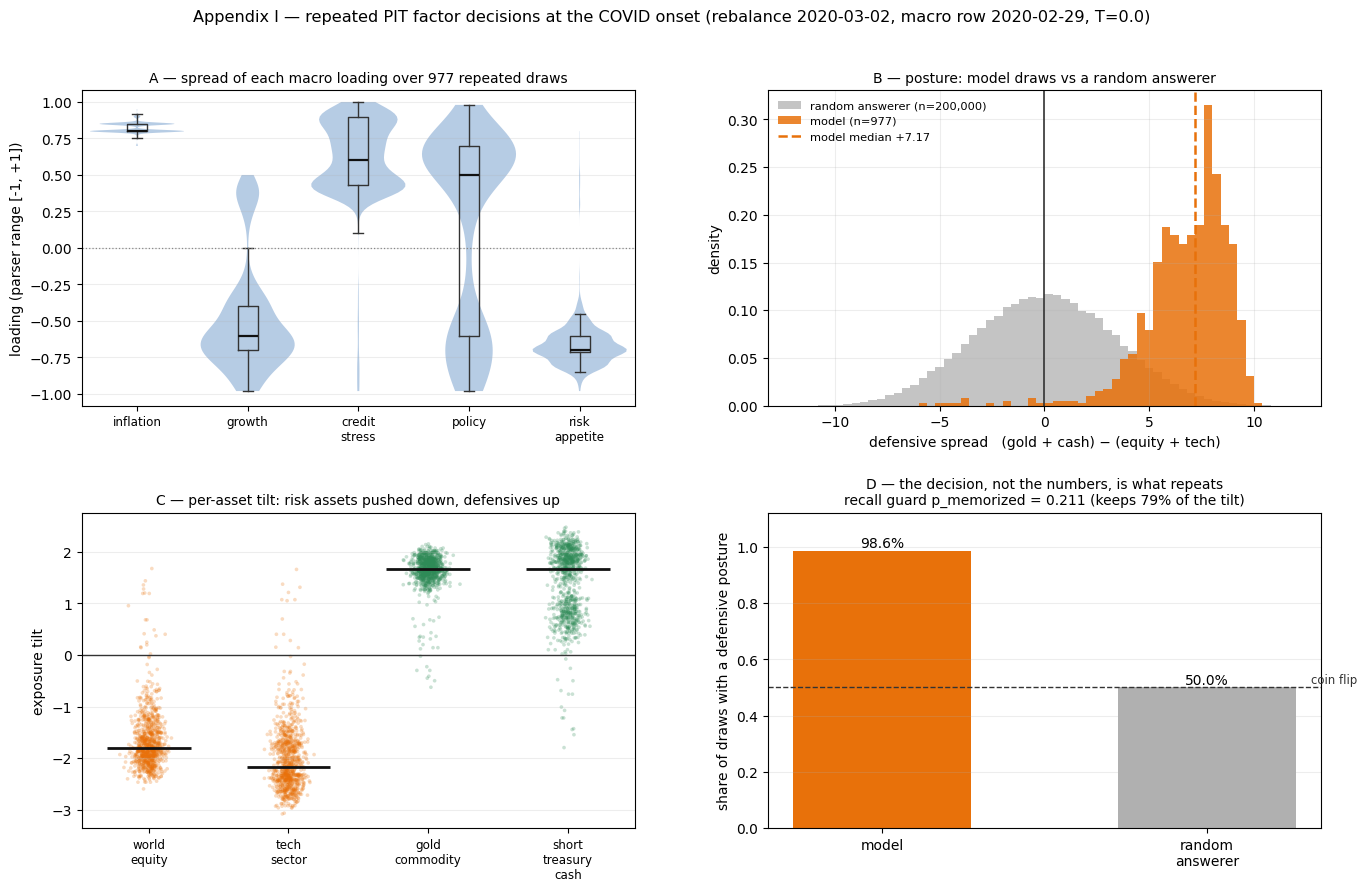

figure: /home/mc/projects/Global_Macro_AI_Factors/data/appendix_i_factor_dispersion/appendix_i_factor_dispersion.png


In [6]:
fig = plt.figure(figsize=(13.4, 9.0))
gs = fig.add_gridspec(2, 2, hspace=0.34, wspace=0.24)
ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax_c, ax_d = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])

AXIS_COLOR = "#2f6db3"
NULL_COLOR = "#b0b0b0"
MODEL_COLOR = "#e8710a"
DEF_COLOR = "#2e8b57"

# A - per-axis spread of the repeated answers
positions = np.arange(len(AXES))
parts = ax_a.violinplot([parsed[a].to_numpy(dtype=float) for a in AXES],
                        positions=positions, showextrema=False, widths=0.85)
for body in parts["bodies"]:
    body.set_facecolor(AXIS_COLOR)
    body.set_alpha(0.35)
ax_a.boxplot([parsed[a].to_numpy(dtype=float) for a in AXES], positions=positions,
             widths=0.18, showfliers=False,
             medianprops=dict(color="#111111", lw=1.6),
             boxprops=dict(color="#333333"), whiskerprops=dict(color="#333333"),
             capprops=dict(color="#333333"))
ax_a.axhline(0.0, color="#888888", lw=0.9, ls=":")
ax_a.set_xticks(positions)
ax_a.set_xticklabels([a.replace("_", "\n") for a in AXES], fontsize=8.6)
ax_a.set_ylim(-1.08, 1.08)
ax_a.set_ylabel("loading (parser range [-1, +1])")
ax_a.set_title(f"A — spread of each macro loading over {n_parsed} repeated draws", fontsize=10)
ax_a.grid(alpha=0.22, axis="y")

# B - model posture vs the random answerer
bins = np.linspace(-MAX_SPREAD, MAX_SPREAD, 61)
ax_b.hist(null_spread, bins=bins, density=True, color=NULL_COLOR, alpha=0.75,
          label=f"random answerer (n={N_NULL:,})")
ax_b.hist(parsed_spread, bins=bins, density=True, color=MODEL_COLOR, alpha=0.85,
          label=f"model (n={n_parsed})")
ax_b.axvline(0.0, color="#333333", lw=1.2)
ax_b.axvline(float(parsed_spread.median()), color=MODEL_COLOR, lw=1.8, ls="--",
             label=f"model median {parsed_spread.median():+.2f}")
ax_b.set_xlabel("defensive spread   (gold + cash) − (equity + tech)")
ax_b.set_ylabel("density")
ax_b.set_title("B — posture: model draws vs a random answerer", fontsize=10)
ax_b.legend(frameon=False, fontsize=8.2)
ax_b.grid(alpha=0.22)

# C - per-asset tilt distribution
order = RISK_ASSETS + DEFENSIVE_ASSETS
colors = [MODEL_COLOR, MODEL_COLOR, DEF_COLOR, DEF_COLOR]
for i, (cat, color) in enumerate(zip(order, colors)):
    values = tilts[cat].to_numpy(dtype=float)
    ax_c.scatter(np.full(len(values), i) + rng.normal(0, 0.055, len(values)),
                 values, s=7, alpha=0.25, color=color, edgecolors="none")
    ax_c.hlines(np.median(values), i - 0.3, i + 0.3, color="#111111", lw=2.0, zorder=3)
ax_c.axhline(0.0, color="#333333", lw=1.0)
ax_c.set_xticks(range(len(order)))
ax_c.set_xticklabels([c.replace("_", "\n") for c in order], fontsize=8.6)
ax_c.set_ylabel("exposure tilt")
ax_c.set_title("C — per-asset tilt: risk assets pushed down, defensives up", fontsize=10)
ax_c.grid(alpha=0.22, axis="y")

# D - share defensive, model vs null (with the guard, when sampled)
labels = ["model", "random\nanswerer"]
values = [model_defensive, null_defensive]
bars = ax_d.bar(labels, values, color=[MODEL_COLOR, NULL_COLOR], width=0.55)
ax_d.axhline(0.5, color="#333333", lw=1.0, ls="--")
ax_d.text(1.32, 0.515, "coin flip", fontsize=8.4, color="#333333")
for bar, value in zip(bars, values):
    ax_d.annotate(f"{value:.1%}", (bar.get_x() + bar.get_width() / 2, value),
                  ha="center", va="bottom", fontsize=10)
ax_d.set_ylim(0, 1.12)
ax_d.set_ylabel("share of draws with a defensive posture")
title_d = "D — the decision, not the numbers, is what repeats"
if p_mem is not None:
    title_d += f"\nrecall guard p_memorized = {p_mem.mean():.3f} (keeps {(1 - p_mem).mean():.0%} of the tilt)"
ax_d.set_title(title_d, fontsize=10)
ax_d.grid(alpha=0.22, axis="y")

fig.suptitle(
    f"Appendix I — repeated PIT factor decisions at the COVID onset "
    f"(rebalance {REBALANCE}, macro row {MACRO_SOURCE}, T={TEMPERATURE})",
    fontsize=11.6,
)
fig.subplots_adjust(top=0.89, bottom=0.07, left=0.06, right=0.985)
figure_path = STUDY_DIR / "appendix_i_factor_dispersion.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("figure:", figure_path)


## 6. Stored summary

In [7]:
per_axis = summary.reset_index().rename(columns={"index": "axis"})
per_axis.insert(0, "block", "loading_axis")

decision_rows = pd.DataFrame([
    {"block": "decision", "axis": "model_share_defensive", "mean": model_defensive},
    {"block": "decision", "axis": "null_share_defensive", "mean": null_defensive},
    {"block": "decision", "axis": "model_mean_spread", "mean": float(parsed_spread.mean())},
    {"block": "decision", "axis": "model_sd_spread", "mean": float(parsed_spread.std(ddof=1))},
    {"block": "decision", "axis": "model_min_spread", "mean": float(parsed_spread.min())},
    {"block": "decision", "axis": "model_max_spread", "mean": float(parsed_spread.max())},
    {"block": "decision", "axis": "null_mean_spread", "mean": float(null_spread.mean())},
    {"block": "decision", "axis": "null_sd_spread", "mean": float(null_spread.std(ddof=1))},
    {"block": "decision", "axis": "binomial_p_defensive_gt_half", "mean": float(binom.pvalue)},
    {"block": "decision", "axis": "ks_statistic_vs_null", "mean": float(ks.statistic)},
    {"block": "decision", "axis": "ks_p_value_vs_null", "mean": float(ks.pvalue)},
    {"block": "decision", "axis": "n_draws_total", "mean": float(n_total)},
    {"block": "decision", "axis": "n_draws_parsed", "mean": float(n_parsed)},
    {"block": "decision", "axis": "distinct_loading_vectors", "mean": float(exact.nunique())},
])
if p_mem is not None:
    decision_rows = pd.concat([decision_rows, pd.DataFrame([
        {"block": "recall_guard", "axis": "mean_p_memorized", "mean": float(p_mem.mean())},
        {"block": "recall_guard", "axis": "sd_p_memorized", "mean": float(p_mem.std(ddof=1))},
        {"block": "recall_guard", "axis": "min_p_memorized", "mean": float(p_mem.min())},
        {"block": "recall_guard", "axis": "max_p_memorized", "mean": float(p_mem.max())},
    ])], ignore_index=True)

summary_out = pd.concat([per_axis, decision_rows], ignore_index=True)
summary_path = STUDY_DIR / "factor_dispersion_summary.csv"
summary_out.to_csv(summary_path, index=False, float_format="%.6f")
summary_de_path = STUDY_DIR / "factor_dispersion_summary_de.csv"
summary_out.to_csv(summary_de_path, index=False, sep=";", decimal=",", float_format="%.6f")
display(summary_out.round(4))
print("summary:", summary_path)
print("summary (de-DE):", summary_de_path)


,block,axis,mean,median,sd,min,max,range,IQR,p05,p95,mode,mode_share,sign_agreement
0,loading_axis,inflation,0.8235,0.8,0.0327,0.70,0.95,0.25,0.05,0.8,0.85,0.8,0.5189,1.0000
1,loading_axis,growth,-0.5036,-0.6,0.3697,-0.98,0.50,1.48,0.30,-0.9,0.40,-0.7,0.2027,0.8741
2,loading_axis,credit_stress,0.6139,0.6,0.2930,-0.98,1.00,1.98,0.47,0.4,0.90,0.9,0.2088,0.9765
3,loading_axis,policy,0.1421,0.5,0.6596,-0.98,0.98,1.96,1.30,-0.9,0.85,0.7,0.2057,0.6325
4,loading_axis,risk_appetite,-0.6619,-0.7,0.1697,-0.98,0.80,1.78,0.11,-0.8,-0.50,-0.7,0.3777,0.9867
5,decision,model_share_defensive,0.9857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,decision,null_share_defensive,0.5001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,decision,model_mean_spread,6.7732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,decision,model_sd_spread,2.0413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,decision,model_min_spread,-5.7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


summary: /home/mc/projects/Global_Macro_AI_Factors/data/appendix_i_factor_dispersion/factor_dispersion_summary.csv
summary (de-DE): /home/mc/projects/Global_Macro_AI_Factors/data/appendix_i_factor_dispersion/factor_dispersion_summary_de.csv


## 7. What this does and does not establish

**What the numbers say.** Across 977 parsed draws of the *same* prompt the model
produced **652 distinct loading vectors** — it is plainly not reciting one
memorised answer. Yet **98.6%** of those draws imply a defensive posture, against
**50.0%** for a random answerer on the same grid (binomial p < 1e-250; KS
D = 0.82 against the null). The disagreement is concentrated where a forecaster
*should* be uncertain — `policy` is effectively unresolved (sd 0.66, IQR 1.30,
sign agreement 63%) — while the axes that carry the crisis read are stable:
`inflation` sd 0.03, `risk_appetite` negative in 98.7% of draws, `credit_stress`
positive in 97.6%. The model wobbles on the numbers and holds on the decision.

**What followed this decision.** Into the trough four weeks later, the AI
macro-factor drew down −11.4% (2020-03-19) against −15.3% for the static 25%
basket and −33.7% for SPY. The posture the draws agree on is the one that
protected capital.

**The guard is the noisier component.** `p_memorized` averaged 0.211 across 100
scorings of the identical prompt, but ranged 0.00–0.76 (sd 0.22) — wider relative
dispersion than the regime read itself, and above the 0.0 recorded for this date
in the canonical run. On average the guard passes through 79% of the tilt here,
but a single scoring is not a reliable point estimate. That is a limitation of
the guard, not a result about the factor, and it is worth revisiting before any
guard threshold is used as a hard gate.

**Scope limits, stated plainly.**

- One date, one prompt. This measures the stability of a single decision at a
  single crisis onset, not the skill of the strategy. Out-of-sample performance
  is the subject of the trio tear sheets, not of this appendix.
- Stability is not correctness. A model can be consistently wrong. What makes
  the consistency meaningful here is that the repeated posture — away from equity
  and tech, toward gold and cash — is the one the subsequent drawdown rewarded.
- 2020 lies inside the model's training window. That is exactly the risk the
  recall guard exists to price, and why `p_memorized` is reported alongside. This
  appendix does not separate genuine macro reasoning from recall of 2020; it
  shows the reading is reproducible and prices what the guard makes of it.
- The null is uninformed by construction. It shows what "no signal" looks like
  under the same exposure map; it is not a competing forecaster.
- 23 of 1000 draws (2.3%) did not yield a full five-axis vector. They remain in
  the CSV as evidence and are excluded from the statistics; in production such a
  draw falls back to the base allocation rather than a fabricated vector.
